In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ----------------------------------------
# 2. Upload CSV File (User Upload Option)
# ----------------------------------------

print("Upload the HR_comma_sep.csv file")

try:
    # For Google Colab users
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)
except:
    # For local system users
    file_name = input("Enter path of HR_comma_sep.csv file: ")
    df = pd.read_csv(file_name)

Upload the HR_comma_sep.csv file


Saving HR_comma_sep - HR_comma_sep.csv to HR_comma_sep - HR_comma_sep.csv


In [12]:
# ----------------------------------------
# 3. Basic Data Exploration
# ----------------------------------------

print("\nFirst 5 rows of dataset:")
df.head()



First 5 rows of dataset:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [13]:
print("\nDataset Info:")
df.info()




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [14]:
print("\nChecking missing values:")
df.isnull().sum()


Checking missing values:


,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


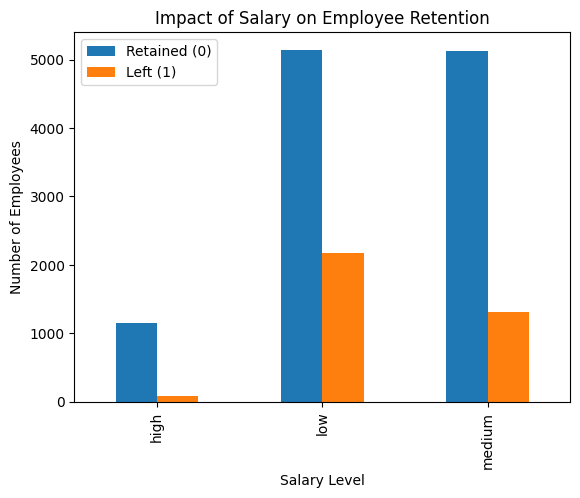

In [6]:
# ----------------------------------------
# 4. Impact of Salary on Retention
# ----------------------------------------

salary_retention = pd.crosstab(df['salary'], df['left'])
salary_retention.plot(kind='bar')

plt.title("Impact of Salary on Employee Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.legend(["Retained (0)", "Left (1)"])
plt.show()

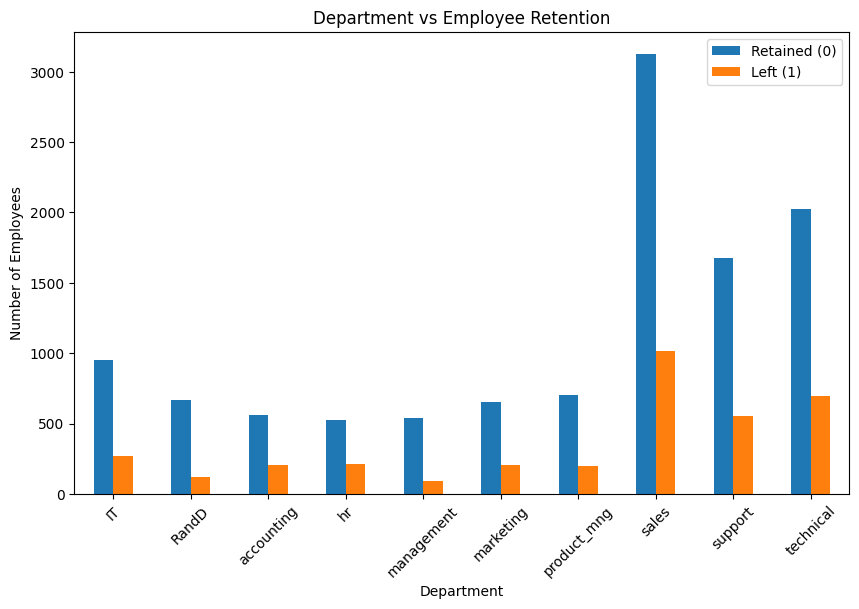

In [7]:
# ----------------------------------------
# 5. Correlation Between Department and Retention
# ----------------------------------------

dept_retention = pd.crosstab(df['Department'], df['left'])
dept_retention.plot(kind='bar', figsize=(10,6))

plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.legend(["Retained (0)", "Left (1)"])
plt.xticks(rotation=45)
plt.show()

In [8]:

# ----------------------------------------
# 6. Feature Selection
# ----------------------------------------
# Based on typical HR dataset observation:
# Important features:
# satisfaction_level
# average_montly_hours
# promotion_last_5years
# salary (categorical)

# Select features
X = df[['satisfaction_level',
        'average_montly_hours',
        'promotion_last_5years',
        'salary']]

y = df['left']

# Convert salary into dummy variables
X = pd.get_dummies(X, drop_first=True)

In [10]:
# ----------------------------------------
# 7. Train Test Split
# ----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ----------------------------------------
# 8. Build Logistic Regression Model
# ----------------------------------------

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ----------------------------------------
# 9. Predictions
# ----------------------------------------

y_pred = model.predict(X_test)

# ----------------------------------------
# 10. Model Accuracy
# ----------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))




Model Accuracy: 0.7675555555555555

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86      3428
           1       0.53      0.24      0.33      1072

    accuracy                           0.77      4500
   macro avg       0.66      0.59      0.59      4500
weighted avg       0.73      0.77      0.73      4500



In [11]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[3196  232]
 [ 814  258]]
